# DS2000 & DS2001 Programming with Data & Practicum

# Lab 6: Sampling and Simulations

#### Today's lab

Welcome to Lab 6! In today's lab, you'll learn about sampling and continue practicing simulation.

Reading:

* [9.3 Simulations](https://www.inferentialthinking.com/chapters/09/3/Simulation.html)
* [10. Sampling](https://inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)

First, set up the tests and imports by running the cell below.

In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import otter
grader = otter.Notebook("lab06.ipynb")

## 1. Sampling Basketball Data

Run the cell below to load player and salary data. We join the two tables to form the `full_data` table from which we will sample.  

In [2]:
player_data = Table().read_table("player_data.csv")
salary_data = Table().read_table("salary_data.csv")
full_data = salary_data.join("PlayerName", player_data, "Name")

# The show method immediately displays the contents of a table. 
player_data.show(3)
salary_data.show(3)
full_data.show(3)

Name,Age,Team,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
James Harden,25,HOU,81,459,565,154,60,321,2217
Chris Paul,29,LAC,82,376,838,156,15,190,1564
Stephen Curry,26,GSW,80,341,619,163,16,249,1900


PlayerName,Salary
Kobe Bryant,23500000
Amar'e Stoudemire,23410988
Joe Johnson,23180790


PlayerName,Salary,Age,Team,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
A.J. Price,62552,28,TOT,26,32,46,7,0,14,133
Aaron Brooks,1145685,30,CHI,82,166,261,54,15,157,954
Aaron Gordon,3992040,19,ORL,47,169,33,21,22,38,243


Rather than getting data on every player (as in the tables loaded above), imagine that we had gotten data on only a smaller subset of the players.  

If we want to make estimates about a certain numerical property of the population (known as a statistic, e.g. the mean or median), we may have to come up with these estimates based only on a smaller sample. Whether these estimates are useful or not often depends on how the sample was gathered. We have prepared some example sample datasets to see how they compare to the full NBA dataset. Later we'll ask you to create your own samples to see how they behave.

To save typing and increase the clarity of your code, we will package the analysis code into a few functions. This will be useful in the rest of the lab as we will repeatedly need to create histograms and collect summary statistics from that data.

We've defined the `histograms` function below, which takes a table with columns `Age` and `Salary` and draws a histogram for each one. It uses bin widths of 1 year for `Age` and $1,000,000 for `Salary`.

Two histograms should be displayed below


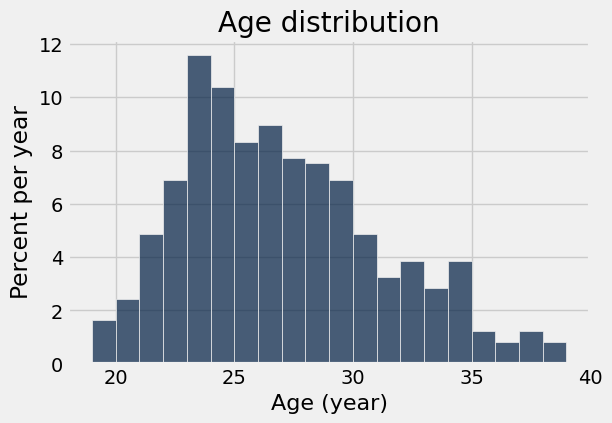

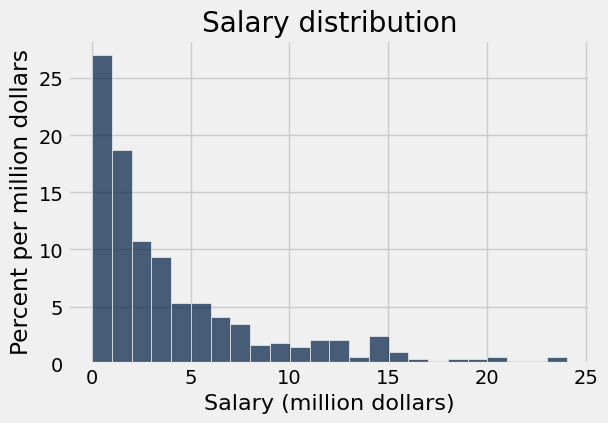

In [3]:
def histograms(t):
    ages = t.column('Age')
    salaries = t.column('Salary')/1000000
    t1 = t.drop('Salary').with_column('Salary', salaries)
    age_bins = np.arange(min(ages), max(ages) + 2, 1) 
    salary_bins = np.arange(min(salaries), max(salaries) + 1, 1)
    t1.hist('Age', bins=age_bins, unit='year')
    plt.title('Age distribution')
    t1.hist('Salary', bins=salary_bins, unit='million dollars')
    plt.title('Salary distribution') 
    
histograms(full_data)
print('Two histograms should be displayed below')

**Question 1.1**. Create a function called `compute_statistics` that takes a table containing ages and salaries and:
- Draws a histogram of ages
- Draws a histogram of salaries
- Returns a two-element array containing the average age and average salary (in that order)

You can call the `histograms` function to draw the histograms! 

array([  2.65365854e+01,   4.26977577e+06])

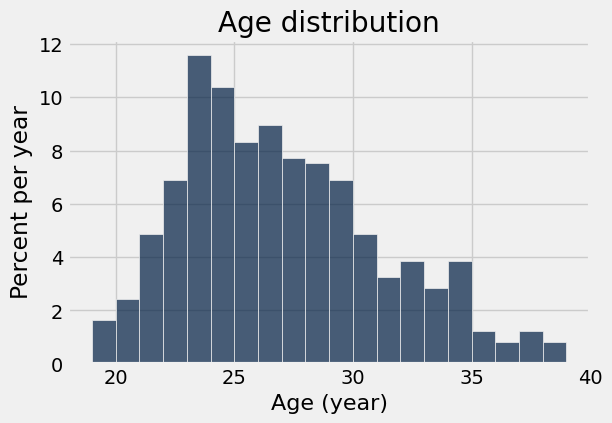

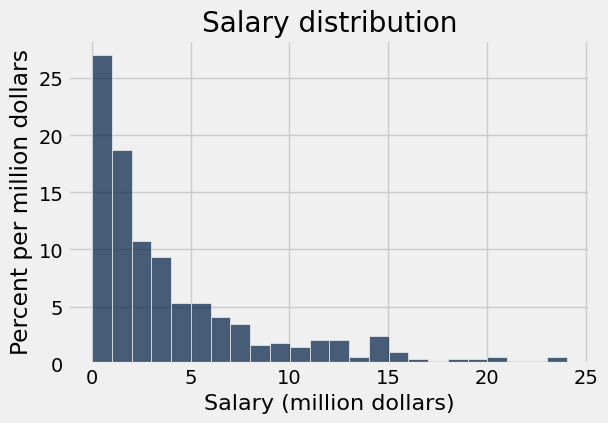

In [4]:
def compute_statistics(age_and_salary_data):
    histograms(age_and_salary_data)   # call the function histograms to plot Ages and Salaries
    age = np.average(age_and_salary_data.column("Age"))
    salary = np.average(age_and_salary_data.column("Salary"))
    return make_array(age, salary)      # return an array with 2 values: the mean age and mean salary

full_stats = compute_statistics(full_data)
full_stats

In [5]:
grader.check("q11")

q11 results: All test cases passed!

### Simple random sampling

In a **simple random sample (SRS) without replacement**, we ensure that when we randomly pick players, each player is selected at most once. Imagine writing down each player's name on a card, putting the cards in an box, and shuffling the box.  Then, pull out cards one by one and set them aside, stopping when the specified sample size is reached.

### Producing simple random samples
Sometimes, it’s useful to take random samples even when we have the data for the whole population. It helps us understand sampling accuracy.

### `sample`

The table method `sample` produces a random sample from the table. By default, it draws at random **with replacement** from the rows of a table. Sampling with replacement means for any row selected randomly, there is a chance it can be selected again if we sample multiple times. Sample takes in the sample size as its argument and returns a **table** with only the rows that were selected. This differs from np.random.choice, which takes an array and outputs a random value from the array. 

Run the cell below to see an example call to `sample()` with a sample size of 5, with replacement.

In [6]:
# Just run this cell

salary_data.sample(5)

PlayerName,Salary
Allen Crabbe,862000
Derrick Williams,6331404
Kenneth Faried,2249768
Tyreke Evans,11265416
Dion Waiters,4062000


The optional argument `with_replacement=False` can be passed through `sample()` to specify that the sample should be drawn **without replacement**.

Run the cell below to see an example call to `sample()` with a sample size of 5, without replacement.

In [7]:
# Just run this cell

salary_data.sample(5, with_replacement=False)

PlayerName,Salary
Tristan Thompson,5138430
Amir Johnson,7000000
Jeremy Lin,14898938
J.J. Redick,6792500
C.J. Miles,4205000


**Question 1.2.** Produce a simple random sample **without** replacement of size **44** from `full_data`. Run your analysis on it again by using the `compute_statistics` function.  Run the cell a few times to see how the histograms and statistics change across different samples.

*Note:* Unless specified otherwise, simple random sample is drawn **without replacement**.

- How much does the average age change across samples? 
- What about average salary?

array([  2.72727273e+01,   4.66877641e+06])

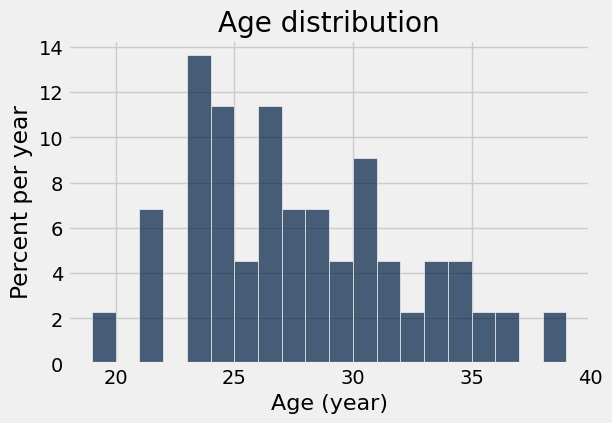

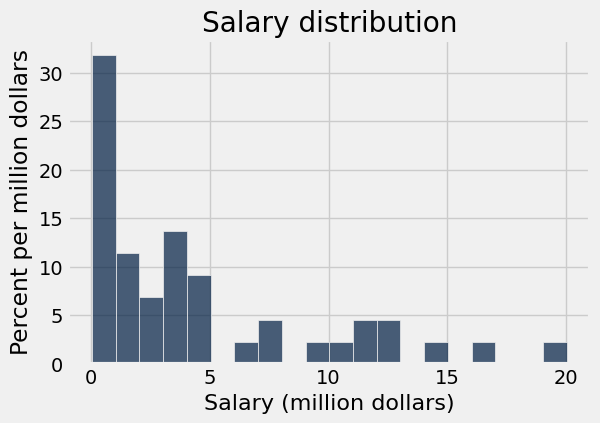

In [8]:
my_small_data = full_data.sample(44, with_replacement=False)
my_small_stats = compute_statistics(my_small_data) 

my_small_stats

For the above sample:

The average age in the above histogram of ages ranges from 20 years of age all the way to about 37 years of age, though the results are most centered around age 25.
The average salary in the above histogram of salaries ranges from less than a million dollars to about 23 million dollars. The results, however, are most centered around players making less than a million dollars or making between 1 and 2 million dollars.

Over multiple samples:

The average age changes by less than a year (or less than 0.1) for each sample I have drawn. So, the average ages range from about 25.8 to 27.0 in the samples I collected.
The average salary changes by more than the average age, changing by less than $1,000,000 (or less than 0.1e+06) for each sample I have drawn. So, the average salary ranges from about 3.2 million dollars to 5.1 million dollars in the samples I have collected.

In [9]:
grader.check("q12")

q12 results: All test cases passed!

**Question 1.3.** As in the previous question, analyze several simple random samples of size 100 from `full_data` by using the `compute_statistics` function.

- Do the histogram shapes seem to change more or less across samples of 100 than across samples of size 44?  
- Are the sample averages and histograms closer to their true values/shape for age or for salary?  What did you expect to see?

array([  2.68100000e+01,   4.91065141e+06])

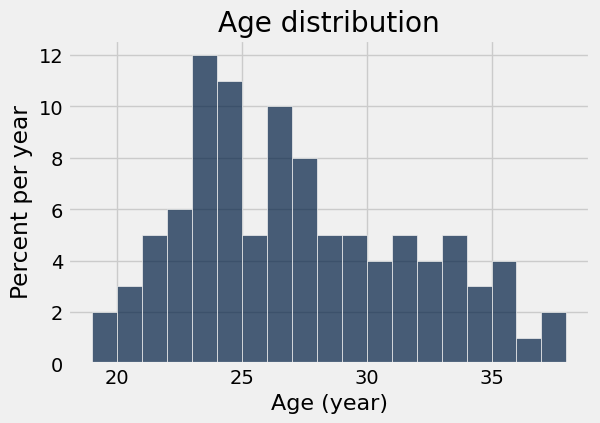

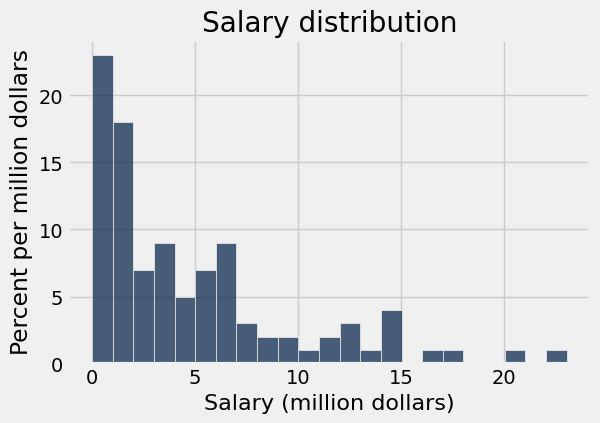

In [10]:
my_large_data = full_data.sample(100, with_replacement=False)
my_large_stats = compute_statistics(my_large_data)

my_large_stats

As the above sample reflects, the averages of the samples for age and salary begin to align more with the average age and average salary of the full data set. A greater sample increases the accuracy of the average, when compared to the full data set, by decreasing the variation of the samples in age and salary.

In [11]:
grader.check("q13")

q13 results: All test cases passed!

## 2. More Practice with Simulations

We can use `np.random.choice` to simulate multiple trials.

**Question 2.1.** Stephanie decides to spend her Friday night rolling a standard six-sided die. She wants to know what her total score would be if she rolled the die 100 times. Write code that simulates her total score after 100 rolls. 

*Hint:* First decide the possible values you can take in the experiment with one roll (point values in this case). Then use `np.random.choice` to simulate Stephanie’s rolls. Finally, sum up the rolls to get Stephanie's total score.

In [12]:
possible_point_values = np.arange(1,7)
simulated_tosses = np.random.choice(possible_point_values, 100)
total_score = sum(simulated_tosses)
total_score

341

In [13]:
grader.check("q21")

q21 results: All test cases passed!

**Question 2.2.** Write a function called `one_hundred_rolls` to simulate Stephanie's game of rolling a die 100 times and totaling up the scores.

In [14]:
def one_hundred_rolls():
    return sum(np.random.choice(np.arange(1,7), 100))

one_hundred_rolls()

337

In [15]:
grader.check("q22")

q22 results: All test cases passed!

Run the following cell a few times to see the total score of 100 rolls.

In [16]:
one_hundred_rolls()

362

**Question 2.3.** Simulate Stephanie playing her one_hundred_rolls game 10000 times.  Make a histogram of the total score distributions (code provided).

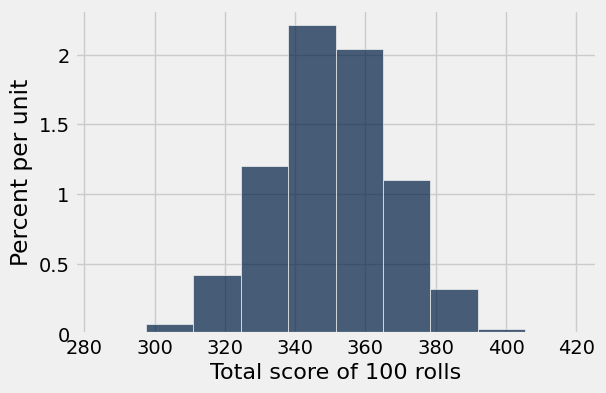

In [17]:
total_scores = make_array()

for i in np.arange(10000):
    total_scores = np.append(total_scores, one_hundred_rolls())

# histogram of the total_scores
Table().with_column('Total score of 100 rolls', total_scores).hist(
    'Total score of 100 rolls')

In [18]:
grader.check("q23")

q23 results: All test cases passed!

**Achilles the turtle** sits on the number line. Achilles loves long random walks that last a total of 100 times steps. At each time step, Achilles moves based on the following scheme: He flips a coin and moves one step to the right if the coin comes up heads or one step to the left if the coin comes up tails. (from Midterm Review Worksheet)

**Question 2.4.** Assuming that Achilles’ coin is fair, write a function called `one_walk` that simulates one random walk of 100 time steps and returns how far from the origin  (this should be a positive number) Achilles ends up at the end of his walk. You may assume that Achilles always starts from the origin.

In [19]:
def one_walk():
    step_left = -1
    step_right = 1
    steps = make_array(step_left, step_right)
    walk = np.random.choice(steps, 100)
    return abs(sum(walk))

In [20]:
grader.check("q24")

q24 results: All test cases passed!

Run the following cell a few times to see the distance of one random walk.

In [21]:
one_walk()

16

**Question 2.5.** Assuming that Achilles’ coin is fair, we would like to simulate what would happen if Achilles took 10000 different random walks. Complete the simulation below and keep track of how far Achilles ends up from the origin in each of his walks in an array called `distances`. Make a histogram of the distribution of `distances`.

A sample histogram looks like:
<img src="Q2.5_graph.PNG" width="400px">

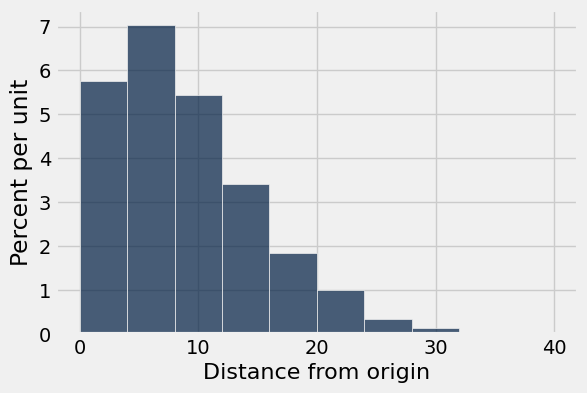

In [22]:
# this code may take some time to run
distances = make_array()

for i in np.arange(10000):
    distances = np.append(distances, one_walk())

# histogram of the distances
Table().with_column("Distance from origin", distances).hist("Distance from origin")

In [23]:
grader.check("q25")

q25 results: All test cases passed!

**Question 2.6.** Achilles goes for a walk and claims that at the end of his walk, he ended up 35 steps away from the origin which happens to be the location of an ice cream store.  Does it seem to you that Achilles took a **random** walk?  What question(s) would you ask Achilles?

It does not seem to me like Achilles took a random walk because repeated histograms of 10,000 random 100 time step walks do not show any walks at which he ended up 35 steps or more from the origin. Given these results, it is very unlikely that Achilles' walk was random. I would ask him by which method he chose the direction of his steps. If he "randomly" chose the steps himself, there is implicit bias, given people are often unable to make truly random choices.

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [24]:
grader.check_all()

q11 results: All test cases passed!

q12 results: All test cases passed!

q13 results: All test cases passed!

q21 results: All test cases passed!

q22 results: All test cases passed!

q23 results: All test cases passed!

q24 results: All test cases passed!

q25 results: All test cases passed!

Congratulations, you're done with Lab 6! 

Be sure to:
- **run** all the tests 
- **save** your notebook and **download** a pdf version of it,
- **submit** your work to Gradescope.